# Johnson Nestedness Analysis - VC Syndication Networks

This notebook analyzes nestedness using Johnson et al. (2013) metric for venture capital syndication networks.

**Key Concept**: Johnson's nestedness measures how specialist nodes connect only to generalist nodes,
creating a hierarchical nested structure in bipartite networks.

- **g_norm**: Global normalized nestedness (observed / configuration model expectation)
- **g_raw**: Raw global nestedness
- **local nestedness**: Individual node contributions to overall nestedness

## Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite
import seaborn as sns
from matplotlib.lines import Line2D
import sys
import os
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr

# Add libs directory to path
sys.path.append('../libs')

# Import custom nestedness libraries
from johnson_nestedness_calculator import JohnsonNestednessCalculator
from curveball import find_presences, curve_ball

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 12)

# Configuration
target_communities = [0, 1, 2]
figures_dir = '../../reports/figures/us/johnson_nestedness'
os.makedirs(figures_dir, exist_ok=True)

In [2]:
# Load the data
nodes_df = pd.read_csv('../../data/processed/us/nodes.csv')
edges_df = pd.read_csv('../../data/processed/us/edges.csv')

print(f"Nodes shape: {nodes_df.shape}")
print(f"Edges shape: {edges_df.shape}")
print(f"\nNumber of unique communities: {nodes_df['community_id'].nunique()}")
print(f"\nNodes columns: {nodes_df.columns.tolist()}")
print(f"Edges columns: {edges_df.columns.tolist()}")

Nodes shape: (15347, 7)
Edges shape: (156481, 24)

Number of unique communities: 171

Nodes columns: ['index', 'index.1', 'community_id', 'node', 'community_size', 'id', 'set']
Edges columns: ['index', 'investor_name_left', 'investor_name_right', 'announced_year_left', 'announced_year_right', 'org_uuid', 'total_funding_usd', 'total_funding_usd_left', 'total_funding_usd_right', 'year', 'company_country', 'investor_country_left', 'investor_country_right', 'investor_region_left', 'investor_region_right', 'investment_type_left', 'investment_type_right', 'category_left', 'category_right', 'community_left', 'community_right', 'community', 'Source', 'Target']


In [3]:
# Calculate degree for each node
source_degrees = edges_df['Source'].value_counts()
target_degrees = edges_df['Target'].value_counts()
all_degrees = pd.concat([source_degrees, target_degrees]).groupby(level=0).sum()

degree_df = pd.DataFrame({
    'node': all_degrees.index,
    'degree': all_degrees.values
})

# Merge with nodes
nodes_with_degree = nodes_df.merge(degree_df, on='node', how='left')
nodes_with_degree['degree'] = nodes_with_degree['degree'].fillna(0).astype(int)

print(f"Nodes with degree calculated: {len(nodes_with_degree)}")
print(f"Mean degree: {nodes_with_degree['degree'].mean():.2f}")
print(f"Max degree: {nodes_with_degree['degree'].max()}")

# Display sample
print(f"\nSample nodes:")
print(nodes_with_degree.head())

Nodes with degree calculated: 15347
Mean degree: 20.39
Max degree: 1436

Sample nodes:
   index  index.1  community_id                          node  community_size  \
0      0        0             0  Ironspring Ventures-series_a            4212   
1      1        1             0                 Bolt-series_a            4212   
2      2        2             0          NightDragon-series_e            4212   
3      3        3             0                Xfund-series_e            4212   
4      4        4             0   Borderless Capital-series_b            4212   

                             id  set  degree  
0  Ironspring Ventures-series_a    1      14  
1                 Bolt-series_a    1      34  
2          NightDragon-series_e    0      16  
3                Xfund-series_e    0      12  
4   Borderless Capital-series_b    0      21  


## Helper Functions

In [4]:
def filter_zero_rows_cols(adjacency_matrix):
    """
    Filter out rows and columns that contain only zeros from adjacency matrix.
    This prevents errors in nestedness calculation.
    
    Parameters:
    -----------
    adjacency_matrix : np.ndarray
        Binary adjacency matrix
    
    Returns:
    --------
    filtered_matrix : np.ndarray
        Filtered adjacency matrix with no zero-only rows or columns
    row_indices : np.ndarray
        Boolean mask indicating which rows were kept
    col_indices : np.ndarray
        Boolean mask indicating which columns were kept
    """
    # Identify rows and columns with at least one non-zero entry
    row_mask = adjacency_matrix.sum(axis=1) > 0
    col_mask = adjacency_matrix.sum(axis=0) > 0
    
    # Filter the matrix
    filtered_matrix = adjacency_matrix[row_mask][:, col_mask]
    
    return filtered_matrix, row_mask, col_mask

## Johnson Nestedness Calculation

Following Johnson et al. (2013), we calculate:
- **g_raw**: Observed nestedness
- **g_conf**: Expected nestedness under configuration model
- **g_norm = g_raw / g_conf**: Normalized nestedness

**Interpretation**:
- g_norm > 1 → More nested than expected (specialist-generalist hierarchy)
- g_norm < 1 → Less nested than expected (anti-nested)
- g_norm ≈ 1 → Random structure (no nestedness)

In [5]:
def calculate_johnson_nestedness(
        selected_nodes,
        selected_edges,
        label="Network",
        return_local=True
):
    """
    Calculate Johnson nestedness for a bipartite network.
    
    Following Johnson et al. (2013), this computes g_norm = g_raw / g_conf,
    where g_conf is the analytical expectation under the configuration model.
    
    g_norm > 1 indicates the network is MORE nested than expected by degree distribution alone.
    g_norm < 1 indicates LESS nested (anti-nested).
    
    Parameters:
    -----------
    selected_nodes : pd.DataFrame
        DataFrame with columns: 'node', 'set' (0 or 1 for bipartite sets)
    selected_edges : pd.DataFrame
        DataFrame with columns: 'Source', 'Target'
    label : str
        Label for the network (e.g., "Community 0")
    return_local : bool
        If True, return local nestedness per node
    
    Returns:
    --------
    dict with keys:
        - 'label': network label
        - 'g_norm': normalized nestedness (observed / expected)
        - 'g_raw': raw nestedness score
        - 'g_conf': configuration model expectation
        - 'adjacency_matrix': the adjacency matrix used
        - 'num_edges': number of edges
        - 'left_nodes': number of left nodes
        - 'right_nodes': number of right nodes
        - 'density': matrix density
        - 'local_g_norm': local normalized nestedness per node (if return_local=True)
        - 'local_g_raw': local raw nestedness per node (if return_local=True)
        - 'node_labels': node names in order of local arrays (if return_local=True)
        - 'node_sets': bipartite set (0/1) for each node (if return_local=True)
    """
    
    # 1. Separate nodes by bipartite set
    left_nodes = selected_nodes[selected_nodes['set'] == 0]['node'].values
    right_nodes = selected_nodes[selected_nodes['set'] == 1]['node'].values
    
    if len(left_nodes) == 0 or len(right_nodes) == 0:
        print(f"ERROR: {label} - Empty bipartite set")
        return None
    
    # 2. Create node indices
    left_indices = {node: i for i, node in enumerate(left_nodes)}
    right_indices = {node: j for j, node in enumerate(right_nodes)}
    
    # 3. Create adjacency matrix (rows = set 0, cols = set 1)
    adjacency_matrix = np.zeros((len(left_nodes), len(right_nodes)), dtype=np.int8)
    
    for _, edge in selected_edges.iterrows():
        source = edge['Source']
        target = edge['Target']
        
        if source in left_indices and target in right_indices:
            adjacency_matrix[left_indices[source], right_indices[target]] = 1
        elif target in left_indices and source in right_indices:
            adjacency_matrix[left_indices[target], right_indices[source]] = 1
    
    # 4. Filter: Remove rows and columns with only zeros
    adjacency_matrix_filtered, row_mask, col_mask = filter_zero_rows_cols(adjacency_matrix)
    
    num_edges = int(adjacency_matrix_filtered.sum())
    density = adjacency_matrix_filtered.mean() if adjacency_matrix_filtered.size > 0 else 0.0
    
    print(f"\n{label}:")
    print(f"  Matrix shape: {adjacency_matrix_filtered.shape[0]} × {adjacency_matrix_filtered.shape[1]}")
    print(f"  Edges: {num_edges}, Density: {density:.4f}")
    
    if num_edges == 0:
        print(f"  ERROR: No edges in adjacency matrix")
        return None
    
    if adjacency_matrix_filtered.shape[0] == 0 or adjacency_matrix_filtered.shape[1] == 0:
        print(f"  ERROR: Empty matrix after filtering")
        return None
    
    # 5. Calculate Johnson nestedness
    try:
        calc = JohnsonNestednessCalculator(adjacency_matrix_filtered)
        result = calc.nestedness(return_local=return_local)
        
        g_raw = result["g_raw"]
        g_norm = result["g_norm"]
        g_conf = result["g_conf"]
        local_g_raw = result["local_raw"]
        local_g_norm = result["local_norm"]
        
        print(f"  g_norm (normalized): {g_norm:.4f}")
        print(f"  g_raw (observed):    {g_raw:.6f}")
        print(f"  g_conf (expected):   {g_conf:.6f}")
        
        # Interpretation
        if g_norm > 1.0:
            interpretation = f"MORE NESTED than expected ({g_norm:.2f}x)"
        elif g_norm < 1.0:
            interpretation = f"LESS NESTED than expected ({g_norm:.2f}x)"
        else:
            interpretation = "RANDOM (no nestedness)"
        print(f"  → {interpretation}")
        
    except Exception as e:
        print(f"  ERROR calculating Johnson nestedness: {e}")
        return None
    
    # 6. Prepare node labels for local nestedness
    node_labels = None
    node_sets = None
    if return_local:
        left_filtered = left_nodes[row_mask]
        right_filtered = right_nodes[col_mask]
        node_labels = list(left_filtered) + list(right_filtered)
        node_sets = [0] * len(left_filtered) + [1] * len(right_filtered)
    
    return {
        'label': label,
        'g_norm': g_norm,
        'g_raw': g_raw,
        'g_conf': g_conf,
        'adjacency_matrix': adjacency_matrix_filtered,
        'num_edges': num_edges,
        'left_nodes': adjacency_matrix_filtered.shape[0],
        'right_nodes': adjacency_matrix_filtered.shape[1],
        'density': density,
        'local_g_norm': local_g_norm,
        'local_g_raw': local_g_raw,
        'node_labels': node_labels,
        'node_sets': node_sets,
    }

## Apply to All Communities

Calculate Johnson nestedness for communities 0, 1, and 2.

In [6]:
# Calculate Johnson nestedness for each community
print("="*80)
print("JOHNSON NESTEDNESS CALCULATION FOR ALL COMMUNITIES")
print("="*80)

johnson_results = []

for comm_id in target_communities:
    print(f"\n{'='*60}")
    print(f"COMMUNITY {comm_id}")
    print(f"{'='*60}")
    
    # Get all nodes and edges for this community
    community_nodes = nodes_with_degree[nodes_with_degree['community_id'] == comm_id].copy()
    community_node_ids = set(community_nodes['node'].values)
    
    community_edges = edges_df[
        (edges_df['Source'].isin(community_node_ids)) & 
        (edges_df['Target'].isin(community_node_ids))
    ]
    
    print(f"Total nodes: {len(community_nodes)} (Set 0: {(community_nodes['set'] == 0).sum()}, Set 1: {(community_nodes['set'] == 1).sum()})")
    print(f"Total edges: {len(community_edges)}")
    
    # Calculate Johnson nestedness
    result = calculate_johnson_nestedness(
        community_nodes,
        community_edges,
        label=f"Community {comm_id}",
        return_local=True
    )
    
    if result is not None:
        johnson_results.append(result)

print(f"\n{'='*80}")
print(f"Successfully calculated nestedness for {len(johnson_results)} communities")
print(f"{'='*80}")

JOHNSON NESTEDNESS CALCULATION FOR ALL COMMUNITIES

COMMUNITY 0
Total nodes: 4212 (Set 0: 2280, Set 1: 1932)
Total edges: 30014

Community 0:
  Matrix shape: 2280 × 1932
  Edges: 28988, Density: 0.0066

Community 0:
  Matrix shape: 2280 × 1932
  Edges: 28988, Density: 0.0066
  g_norm (normalized): 1.3191
  g_raw (observed):    0.000959
  g_conf (expected):   0.000727
  → MORE NESTED than expected (1.32x)

COMMUNITY 1
Total nodes: 4062 (Set 0: 2571, Set 1: 1491)
Total edges: 15378
  g_norm (normalized): 1.3191
  g_raw (observed):    0.000959
  g_conf (expected):   0.000727
  → MORE NESTED than expected (1.32x)

COMMUNITY 1
Total nodes: 4062 (Set 0: 2571, Set 1: 1491)
Total edges: 15378

Community 1:
  Matrix shape: 2571 × 1491
  Edges: 15056, Density: 0.0039

Community 1:
  Matrix shape: 2571 × 1491
  Edges: 15056, Density: 0.0039
  g_norm (normalized): 1.5049
  g_raw (observed):    0.000845
  g_conf (expected):   0.000561
  → MORE NESTED than expected (1.50x)

COMMUNITY 2
Total nodes: 

## Summary Statistics Table

In [7]:
# Create summary table
if len(johnson_results) > 0:
    summary_data = []
    for result in johnson_results:
        summary_data.append({
            'Community': result['label'],
            'Left Nodes': result['left_nodes'],
            'Right Nodes': result['right_nodes'],
            'Edges': result['num_edges'],
            'Density': result['density'],
            'g_norm': result['g_norm'],
            'g_raw': result['g_raw'],
            'g_conf': result['g_conf'],
            'Nestedness': 'High' if result['g_norm'] > 1.2 else 'Moderate' if result['g_norm'] > 0.8 else 'Low'
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    print("\n" + "="*120)
    print("JOHNSON NESTEDNESS SUMMARY TABLE")
    print("="*120)
    print(summary_df.to_string(index=False))
    print("\n" + "="*120)
    
    # Save to CSV
    summary_df.to_csv(os.path.join(figures_dir, 'johnson_nestedness_summary.csv'), index=False)
    print(f"Summary saved to: {os.path.join(figures_dir, 'johnson_nestedness_summary.csv')}")


JOHNSON NESTEDNESS SUMMARY TABLE
  Community  Left Nodes  Right Nodes  Edges  Density   g_norm    g_raw   g_conf Nestedness
Community 0        2280         1932  28988 0.006581 1.319111 0.000959 0.000727       High
Community 1        2571         1491  15056 0.003928 1.504937 0.000845 0.000561       High
Community 2        2910         1130  47076 0.014316 2.532873 0.002544 0.001005       High

Summary saved to: ../../reports/figures/us/johnson_nestedness\johnson_nestedness_summary.csv
Summary saved to: ../../reports/figures/us/johnson_nestedness\johnson_nestedness_summary.csv


## Local Nestedness Analysis

Analyze individual node contributions to overall nestedness.

In [8]:
# Analyze local nestedness for each community
print("\n" + "="*120)
print("LOCAL NESTEDNESS ANALYSIS - INDIVIDUAL NODE CONTRIBUTIONS")
print("="*120)

local_nestedness_data = []

for result in johnson_results:
    if result['local_g_norm'] is None:
        continue
    
    comm_label = result['label']
    node_labels = result['node_labels']
    node_sets = result['node_sets']
    local_g_norm = result['local_g_norm']
    local_g_raw = result['local_g_raw']
    
    print(f"\n{'='*60}")
    print(f"{comm_label}")
    print(f"{'='*60}")
    
    # Create DataFrame for local nestedness
    local_df = pd.DataFrame({
        'node': node_labels,
        'set': node_sets,
        'local_g_norm': local_g_norm,
        'local_g_raw': local_g_raw,
        'community': comm_label
    })
    
    # Add degree information
    local_df = local_df.merge(nodes_with_degree[['node', 'degree']], on='node', how='left')
    
    # Store for later analysis
    local_nestedness_data.append(local_df)
    
    # Statistics by set
    print(f"\nLocal Nestedness Statistics:")
    print(f"-" * 60)
    for set_id in [0, 1]:
        set_data = local_df[local_df['set'] == set_id]
        set_name = 'Set 0 (Late-stage)' if set_id == 0 else 'Set 1 (Early-stage)'
        print(f"\n{set_name}:")
        print(f"  N nodes: {len(set_data)}")
        print(f"  Mean local g_norm: {set_data['local_g_norm'].mean():.6f}")
        print(f"  Median local g_norm: {set_data['local_g_norm'].median():.6f}")
        print(f"  Std local g_norm: {set_data['local_g_norm'].std():.6f}")
        print(f"  Min local g_norm: {set_data['local_g_norm'].min():.6f}")
        print(f"  Max local g_norm: {set_data['local_g_norm'].max():.6f}")
    
    # Top 10 nodes by local nestedness
    print(f"\nTop 10 Nodes by Local Nestedness (g_norm):")
    print(f"-" * 60)
    top_10 = local_df.nlargest(10, 'local_g_norm')[['node', 'set', 'degree', 'local_g_norm', 'local_g_raw']]
    print(top_10.to_string(index=False))
    
    # Bottom 10 nodes by local nestedness
    print(f"\nBottom 10 Nodes by Local Nestedness (g_norm):")
    print(f"-" * 60)
    bottom_10 = local_df.nsmallest(10, 'local_g_norm')[['node', 'set', 'degree', 'local_g_norm', 'local_g_raw']]
    print(bottom_10.to_string(index=False))

# Combine all local nestedness data
if len(local_nestedness_data) > 0:
    all_local_df = pd.concat(local_nestedness_data, ignore_index=True)
    print(f"\n\nTotal nodes analyzed: {len(all_local_df)}")


LOCAL NESTEDNESS ANALYSIS - INDIVIDUAL NODE CONTRIBUTIONS

Community 0

Local Nestedness Statistics:
------------------------------------------------------------

Set 0 (Late-stage):
  N nodes: 2280
  Mean local g_norm: 1.634684
  Median local g_norm: 1.309894
  Std local g_norm: 1.284110
  Min local g_norm: 0.007733
  Max local g_norm: 10.037753

Set 1 (Early-stage):
  N nodes: 1932
  Mean local g_norm: 0.946696
  Median local g_norm: 0.795243
  Std local g_norm: 0.619557
  Min local g_norm: 0.003843
  Max local g_norm: 5.587473

Top 10 Nodes by Local Nestedness (g_norm):
------------------------------------------------------------
                              node  set  degree  local_g_norm  local_g_raw
               PSP Growth-series_e    0       2     10.037753     0.007298
       New Coast Ventures-series_c    0       2     10.037753     0.007298
               PSP Growth-series_f    0       2     10.037753     0.007298
               Cedar Fund-series_c    0       2     10.037

## Visualization: Local Nestedness Distribution

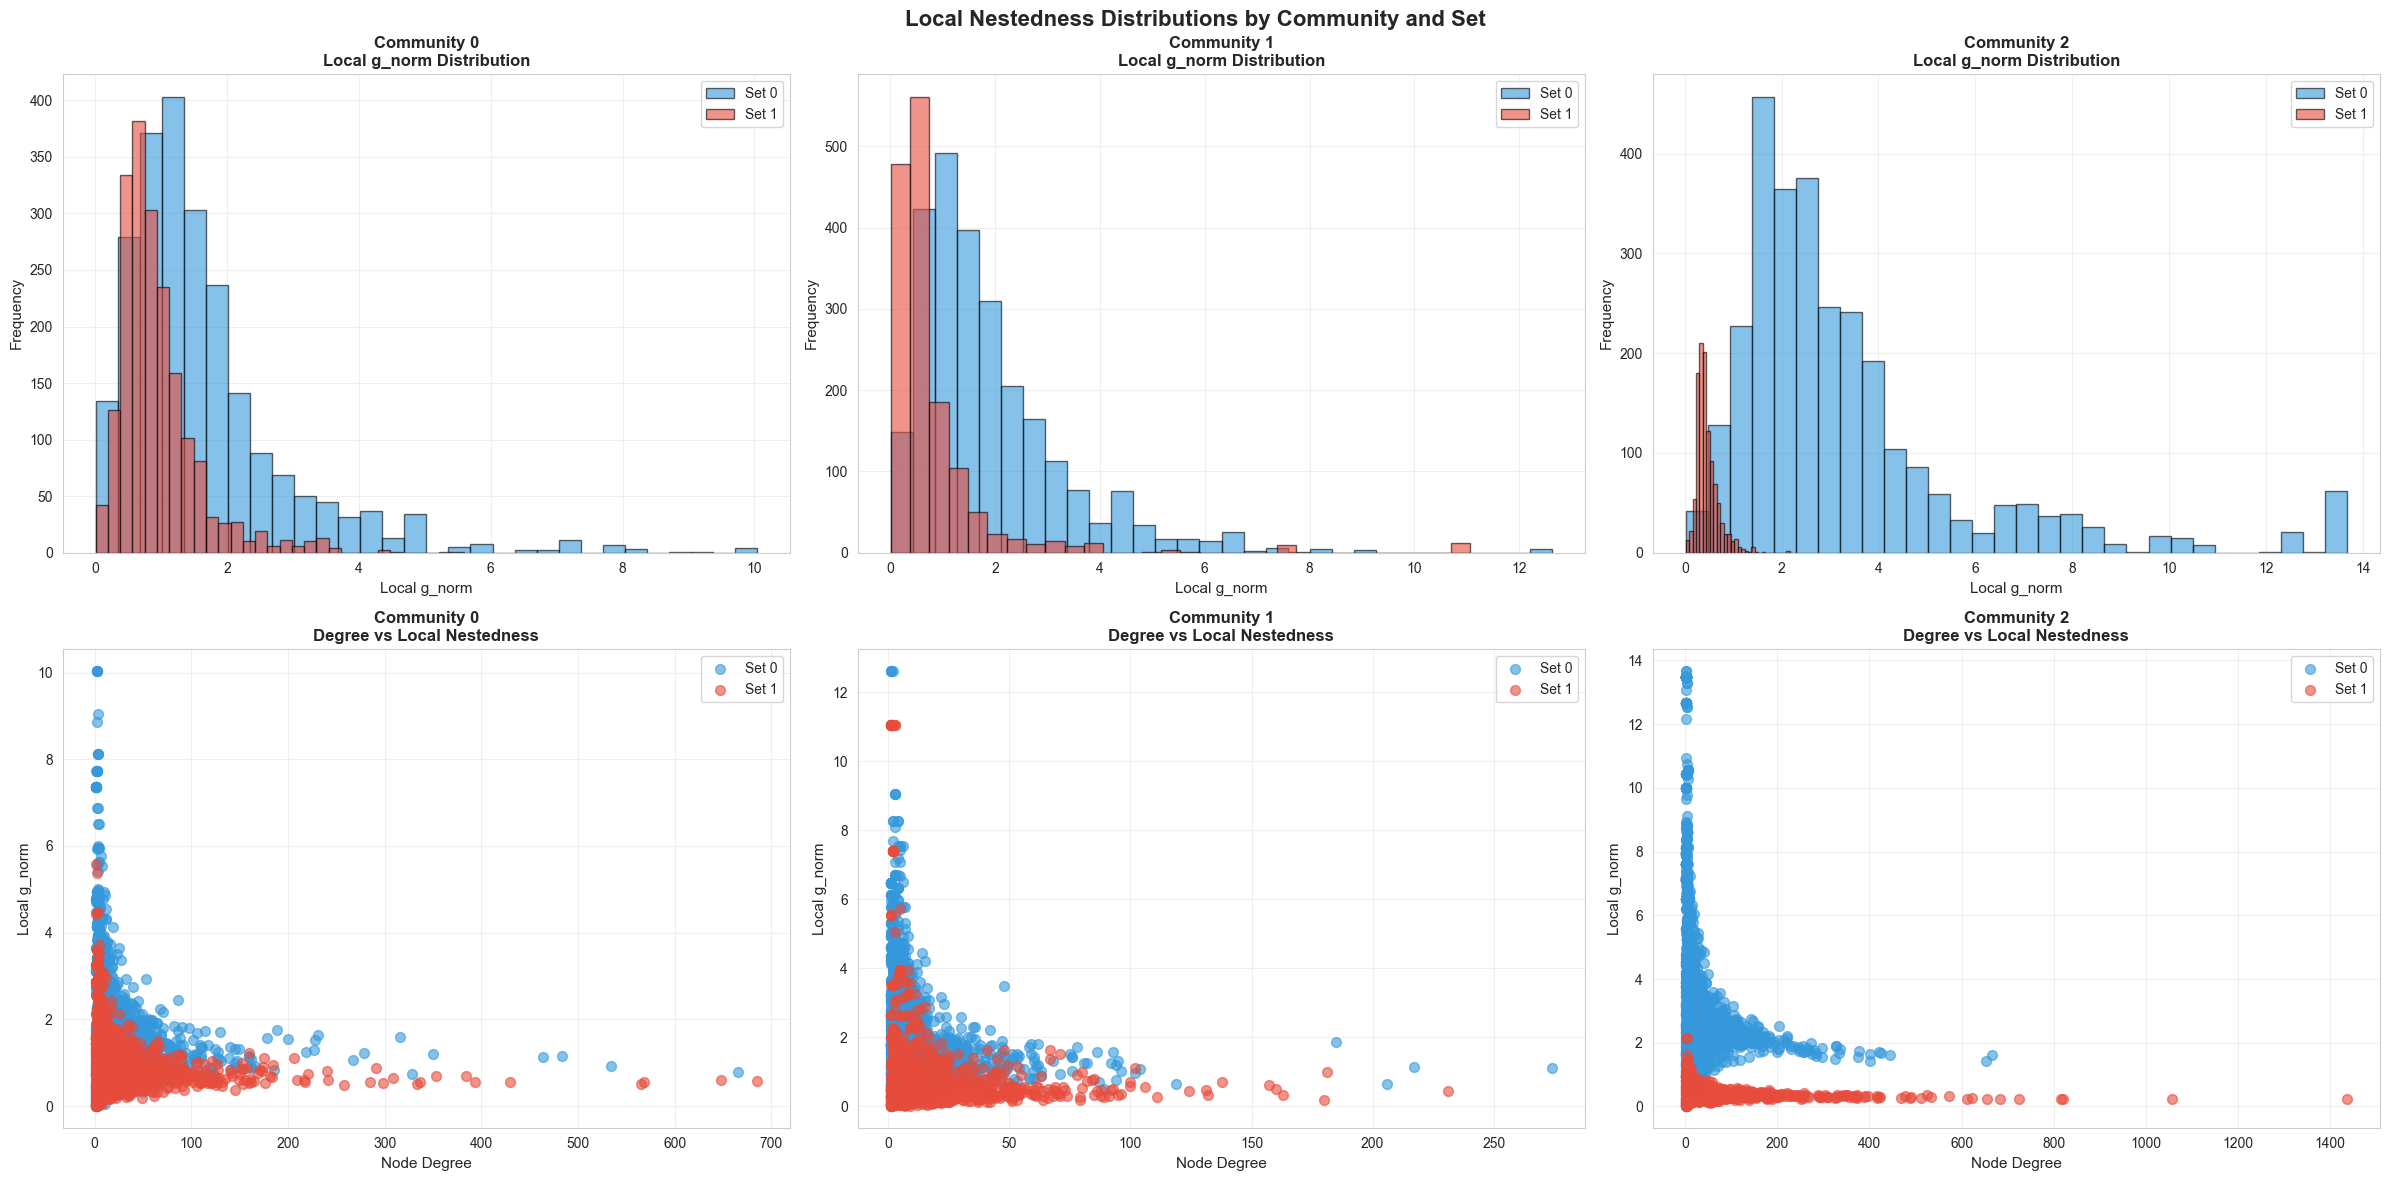

Local nestedness distribution plots saved. Set 0 = Late-stage VCs, Set 1 = Early-stage VCs.


In [15]:
# Plot local nestedness distributions
if len(local_nestedness_data) > 0:
    fig, axes = plt.subplots(2, len(local_nestedness_data), figsize=(8*len(local_nestedness_data), 12))
    
    if len(local_nestedness_data) == 1:
        axes = axes.reshape(-1, 1)
    
    fig.suptitle('Local Nestedness Distributions by Community and Set', fontsize=16, fontweight='bold')
    
    colors = {0: '#3498db', 1: '#e74c3c'}  # Blue for Set 0, Red for Set 1
    
    for idx, local_df in enumerate(local_nestedness_data):
        comm_label = local_df['community'].iloc[0]
        
        # Row 1: Histograms by set
        ax1 = axes[0, idx]
        for set_id in [0, 1]:
            set_data = local_df[local_df['set'] == set_id]['local_g_norm']
            ax1.hist(set_data, bins=30, alpha=0.6, color=colors[set_id], 
                    label=f'Set {set_id}', edgecolor='black')
        
        ax1.set_title(f"{comm_label}\nLocal g_norm Distribution", fontweight='bold')
        ax1.set_xlabel('Local g_norm', fontsize=11)
        ax1.set_ylabel('Frequency', fontsize=11)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Row 2: Scatter plot (degree vs local nestedness)
        ax2 = axes[1, idx]
        for set_id in [0, 1]:
            set_data = local_df[local_df['set'] == set_id]
            ax2.scatter(set_data['degree'], set_data['local_g_norm'], 
                       alpha=0.6, s=50, color=colors[set_id], label=f'Set {set_id}')
        
        ax2.set_title(f"{comm_label}\nDegree vs Local Nestedness", fontweight='bold')
        ax2.set_xlabel('Node Degree', fontsize=11)
        ax2.set_ylabel('Local g_norm', fontsize=11)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, 'local_nestedness_distributions.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Local nestedness distribution plots saved. Set 0 = Late-stage VCs, Set 1 = Early-stage VCs.")

## Correlation Analysis: Degree vs Local Nestedness

In [10]:
# Analyze correlation between degree and local nestedness
print("\n" + "="*120)
print("CORRELATION ANALYSIS: DEGREE VS LOCAL NESTEDNESS")
print("="*120)

for local_df in local_nestedness_data:
    comm_label = local_df['community'].iloc[0]
    
    print(f"\n{'='*60}")
    print(f"{comm_label}")
    print(f"{'='*60}")
    
    # Overall correlation
    valid_data = local_df.dropna(subset=['degree', 'local_g_norm'])
    if len(valid_data) > 2:
        pearson_r, pearson_p = pearsonr(valid_data['degree'], valid_data['local_g_norm'])
        spearman_r, spearman_p = spearmanr(valid_data['degree'], valid_data['local_g_norm'])
        
        print(f"\nOverall (all nodes):")
        print(f"  Pearson correlation:  r={pearson_r:7.4f}, p={pearson_p:.6f}")
        print(f"  Spearman correlation: ρ={spearman_r:7.4f}, p={spearman_p:.6f}")
    
    # By set
    for set_id in [0, 1]:
        set_data = local_df[local_df['set'] == set_id].dropna(subset=['degree', 'local_g_norm'])
        set_name = 'Set 0 (Late-stage)' if set_id == 0 else 'Set 1 (Early-stage)'
        
        if len(set_data) > 2:
            pearson_r, pearson_p = pearsonr(set_data['degree'], set_data['local_g_norm'])
            spearman_r, spearman_p = spearmanr(set_data['degree'], set_data['local_g_norm'])
            
            print(f"\n{set_name}:")
            print(f"  Pearson correlation:  r={pearson_r:7.4f}, p={pearson_p:.6f}")
            print(f"  Spearman correlation: ρ={spearman_r:7.4f}, p={spearman_p:.6f}")


CORRELATION ANALYSIS: DEGREE VS LOCAL NESTEDNESS

Community 0

Overall (all nodes):
  Pearson correlation:  r=-0.1292, p=0.000000
  Spearman correlation: ρ=-0.0943, p=0.000000

Set 0 (Late-stage):
  Pearson correlation:  r=-0.1309, p=0.000000
  Spearman correlation: ρ=-0.1017, p=0.000001

Set 1 (Early-stage):
  Pearson correlation:  r=-0.1451, p=0.000000
  Spearman correlation: ρ=-0.1677, p=0.000000

Community 1

Overall (all nodes):
  Pearson correlation:  r=-0.2206, p=0.000000
  Spearman correlation: ρ=-0.3158, p=0.000000

Set 0 (Late-stage):
  Pearson correlation:  r=-0.1902, p=0.000000
  Spearman correlation: ρ=-0.2518, p=0.000000

Set 1 (Early-stage):
  Pearson correlation:  r=-0.1548, p=0.000000
  Spearman correlation: ρ=-0.1985, p=0.000000

Community 2

Overall (all nodes):
  Pearson correlation:  r=-0.2286, p=0.000000
  Spearman correlation: ρ=-0.4014, p=0.000000

Set 0 (Late-stage):
  Pearson correlation:  r=-0.1993, p=0.000000
  Spearman correlation: ρ=-0.2955, p=0.000000

S

## Comparative Analysis Across Communities

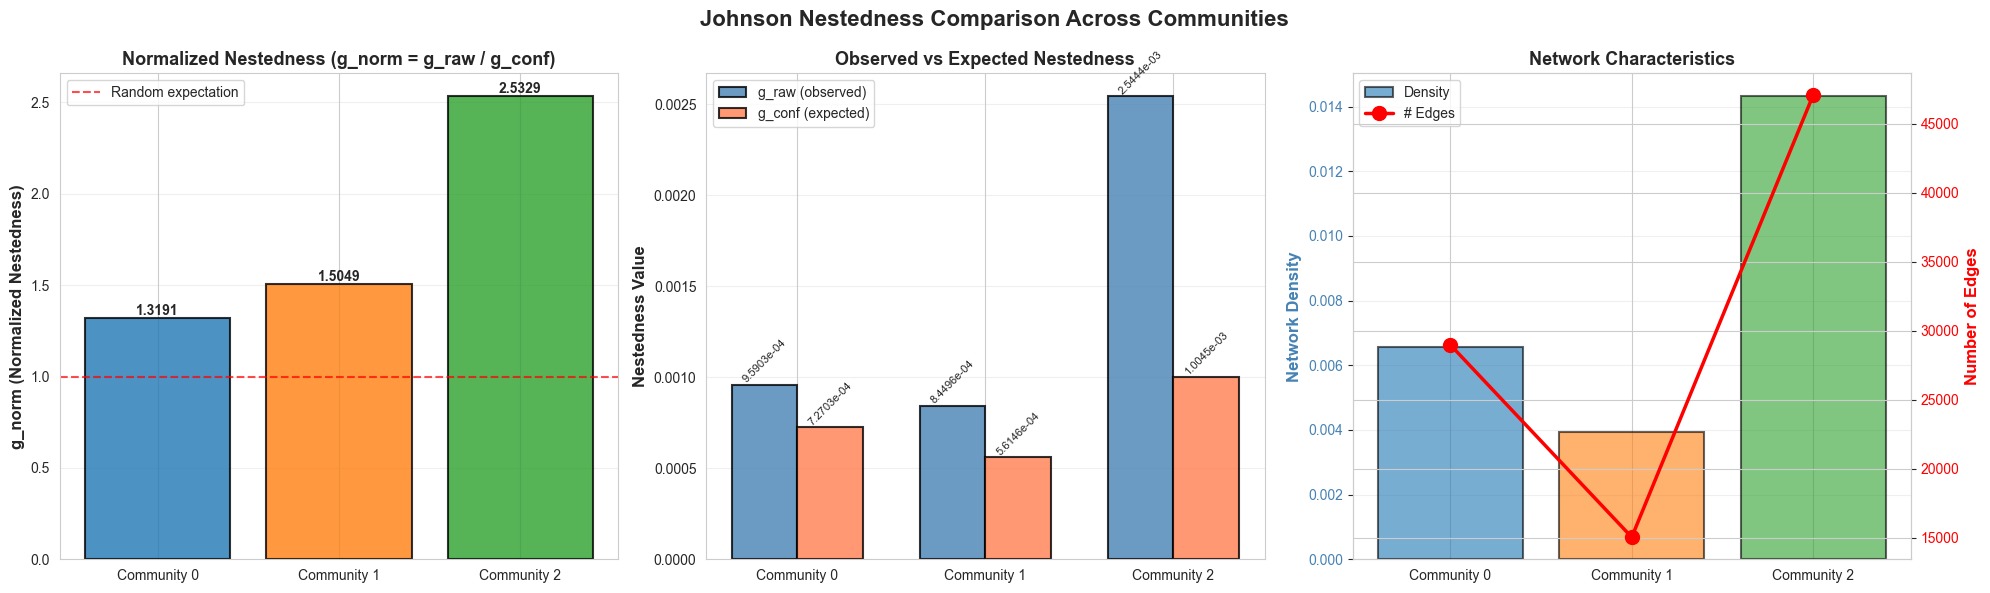

Comparison plot saved


In [14]:
# Comparative bar plot: Observed g_norm across communities
if len(johnson_results) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Johnson Nestedness Comparison Across Communities', fontsize=16, fontweight='bold')
    
    communities = [r['label'] for r in johnson_results]
    g_norm_values = [r['g_norm'] for r in johnson_results]
    g_raw_values = [r['g_raw'] for r in johnson_results]
    g_conf_values = [r['g_conf'] for r in johnson_results]
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    # Plot 1: g_norm (normalized nestedness)
    ax1 = axes[0]
    bars1 = ax1.bar(range(len(communities)), g_norm_values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
    ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Random expectation')
    ax1.set_xticks(range(len(communities)))
    ax1.set_xticklabels(communities)
    ax1.set_ylabel('g_norm (Normalized Nestedness)', fontsize=12, fontweight='bold')
    ax1.set_title('Normalized Nestedness (g_norm = g_raw / g_conf)', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, val in zip(bars1, g_norm_values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Plot 2: g_raw vs g_conf comparison
    ax2 = axes[1]
    x = np.arange(len(communities))
    width = 0.35
    bars2a = ax2.bar(x - width/2, g_raw_values, width, label='g_raw (observed)', 
                    color='steelblue', edgecolor='black', linewidth=1.5, alpha=0.8)
    bars2b = ax2.bar(x + width/2, g_conf_values, width, label='g_conf (expected)', 
                    color='coral', edgecolor='black', linewidth=1.5, alpha=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels(communities)
    ax2.set_ylabel('Nestedness Value', fontsize=12, fontweight='bold')
    ax2.set_title('Observed vs Expected Nestedness', fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar in bars2a:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4e}', ha='center', va='bottom', fontsize=8, rotation=45)
    for bar in bars2b:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4e}', ha='center', va='bottom', fontsize=8, rotation=45)
    
    # Plot 3: Network characteristics
    ax3 = axes[2]
    densities = [r['density'] for r in johnson_results]
    num_edges = [r['num_edges'] for r in johnson_results]
    
    # Normalize for dual-axis plotting
    ax3_twin = ax3.twinx()
    
    bars3 = ax3.bar(range(len(communities)), densities, color=colors, 
                   edgecolor='black', linewidth=1.5, alpha=0.6, label='Density')
    line3 = ax3_twin.plot(range(len(communities)), num_edges, 'ro-', 
                         linewidth=2.5, markersize=10, label='# Edges')
    
    ax3.set_xticks(range(len(communities)))
    ax3.set_xticklabels(communities)
    ax3.set_ylabel('Network Density', fontsize=12, fontweight='bold', color='steelblue')
    ax3_twin.set_ylabel('Number of Edges', fontsize=12, fontweight='bold', color='red')
    ax3.set_title('Network Characteristics', fontsize=13, fontweight='bold')
    ax3.tick_params(axis='y', labelcolor='steelblue')
    ax3_twin.tick_params(axis='y', labelcolor='red')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Combine legends
    lines1, labels1 = ax3.get_legend_handles_labels()
    lines2, labels2 = ax3_twin.get_legend_handles_labels()
    ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, 'johnson_nestedness_comparison.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Comparison plot saved")

## Key Insights and Interpretation

In [12]:
print("\n" + "="*120)
print("KEY INSIGHTS: JOHNSON NESTEDNESS ANALYSIS")
print("="*120)

print("\n" + "-"*120)
print("INSIGHT 1: THE JOHNSON et al. (2013) APPROACH")
print("-"*120)
print("")
print("Johnson nestedness uses an ANALYTICAL baseline (configuration model):")
print("  • g_conf = Expected nestedness from degree distribution alone")
print("  • g_raw  = Observed nestedness in your network")
print("  • g_norm = g_raw / g_conf (the KEY metric)")
print("")
print("NO NUMERICAL NULL MODELS NEEDED:")
print("  • g_norm > 1 → Network is MORE nested than random")
print("  • g_norm < 1 → Network is LESS nested (anti-nested)")
print("  • g_norm ≈ 1 → Nestedness explained by degrees alone")

print("\n" + "-"*120)
print("INSIGHT 2: COMMUNITY COMPARISON")
print("-"*120)

if len(johnson_results) > 0:
    for result in johnson_results:
        ratio = result['g_norm']
        print(f"\n{result['label']}:")
        print(f"  g_norm = {result['g_norm']:.4f}")
        print(f"  g_raw  = {result['g_raw']:.6f} (observed)")
        print(f"  g_conf = {result['g_conf']:.6f} (expected)")
        
        if ratio > 1.2:
            interpretation = f"HIGHLY NESTED ({ratio:.2f}x more than random)"
        elif ratio > 1.0:
            interpretation = f"MODERATELY NESTED ({ratio:.2f}x more than random)"
        elif ratio > 0.8:
            interpretation = f"NEAR RANDOM"
        else:
            interpretation = f"ANTI-NESTED ({ratio:.2f}x less than random)"
        
        print(f"  → {interpretation}")

print("\n" + "-"*120)
print("INSIGHT 3: WHAT THIS MEANS FOR VC NETWORKS")
print("-"*120)
print("")
print("High g_norm (> 1):")
print("  ✓ Specialist VCs connect ONLY with generalist (high-degree) VCs")
print("  ✓ Clear hierarchical structure: core hubs + periphery specialists")
print("  ✓ Access to deals flows through central gatekeepers")
print("")
print("Low g_norm (< 1):")
print("  ✗ Specialists also connect with other specialists")
print("  ✗ More distributed, egalitarian network")
print("  ✗ Multiple pathways to access deals")

print("\n" + "="*120)


KEY INSIGHTS: JOHNSON NESTEDNESS ANALYSIS

------------------------------------------------------------------------------------------------------------------------
INSIGHT 1: THE JOHNSON et al. (2013) APPROACH
------------------------------------------------------------------------------------------------------------------------

Johnson nestedness uses an ANALYTICAL baseline (configuration model):
  • g_conf = Expected nestedness from degree distribution alone
  • g_raw  = Observed nestedness in your network
  • g_norm = g_raw / g_conf (the KEY metric)

NO NUMERICAL NULL MODELS NEEDED:
  • g_norm > 1 → Network is MORE nested than random
  • g_norm < 1 → Network is LESS nested (anti-nested)
  • g_norm ≈ 1 → Nestedness explained by degrees alone

------------------------------------------------------------------------------------------------------------------------
INSIGHT 2: COMMUNITY COMPARISON
------------------------------------------------------------------------------------------

## 

In [ ]:
# Save local nestedness data
if len(local_nestedness_data) > 0:
    all_local_df = pd.concat(local_nestedness_data, ignore_index=True)
    output_path = os.path.join(figures_dir, 'local_johnson_nestedness.csv')
    all_local_df.to_csv(output_path, index=False)
    print(f"\nLocal nestedness data saved to: {output_path}")
    print(f"Shape: {all_local_df.shape}")
    print(f"Columns: {all_local_df.columns.tolist()}")